In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


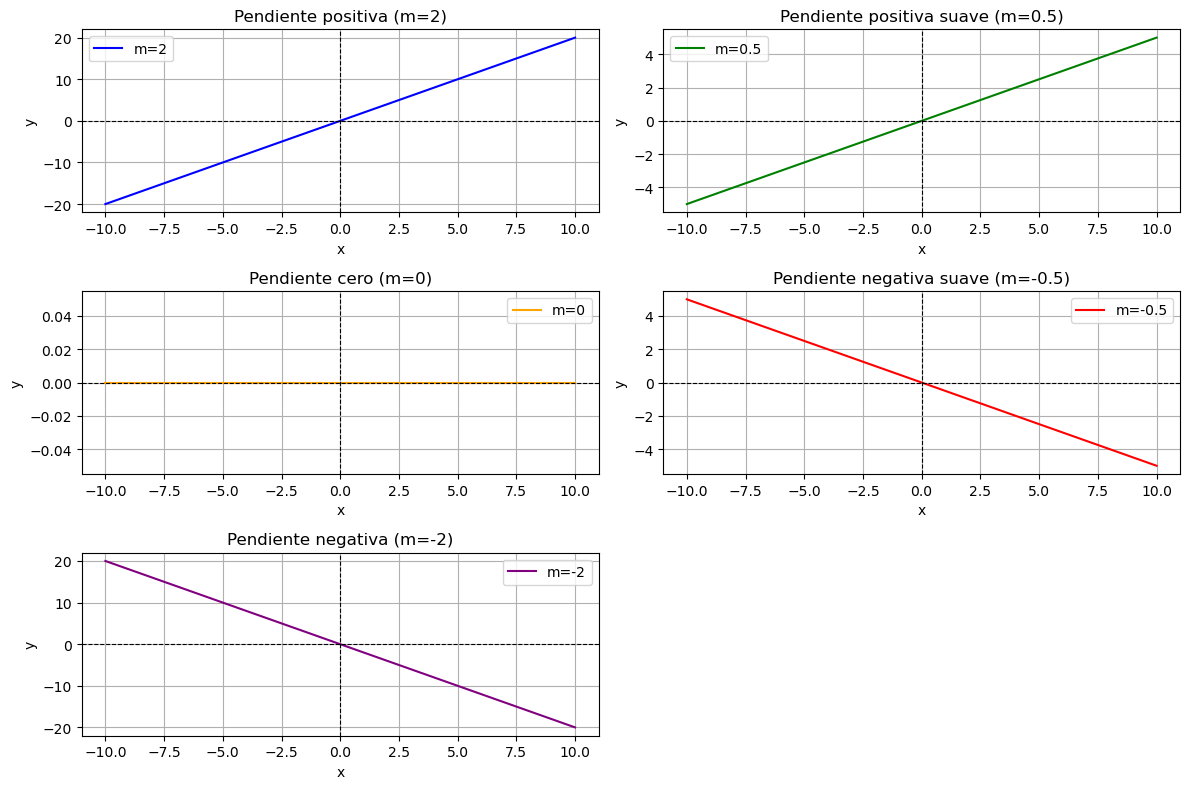

In [32]:
# Configurar las pendientes y colores para los ejemplos
pendientes = [2, 0.5, 0, -0.5, -2]  # Distintas pendientes
intercepto = 0  # Punto de intersección en y = 0
x = np.linspace(-10, 10, 100)  # Valores de x para graficar

# Crear subgráficos para mostrar los ejemplos
plt.figure(figsize=(12, 8))
colores = ['blue', 'green', 'orange', 'red', 'purple']
titulos = ['Pendiente positiva (m=2)', 
           'Pendiente positiva suave (m=0.5)', 
           'Pendiente cero (m=0)', 
           'Pendiente negativa suave (m=-0.5)', 
           'Pendiente negativa (m=-2)']

for i, m in enumerate(pendientes):
    plt.subplot(3, 2, i + 1)
    y = m * x + intercepto  # Ecuación de la recta
    plt.plot(x, y, color=colores[i], label=f"m={m}")
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # Línea x=0
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # Línea y=0
    plt.title(titulos[i])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()


In [33]:

# Configurar semillas para reproducibilidad
np.random.seed(42)

# Datos simulados: Relación lineal clara
edad = np.random.randint(18, 60, 100)  # Edades entre 18 y 60 años
peso = 0.8 * edad + np.random.normal(0, 5, 100)  # Peso lineal con algo de ruido

# Convertir las edades en matriz para la regresión
X = edad.reshape(-1, 1)

# Regresión buena (ajuste correcto)
modelo_bueno = LinearRegression()
modelo_bueno.fit(X, peso)
peso_pred_bueno = modelo_bueno.predict(X)

# Regresión mala (pendiente arbitraria)
peso_pred_malo = 0.2 * edad + 25  # Pendiente y punto de intersección no ajustados

# Grafico de edas vs peso¨

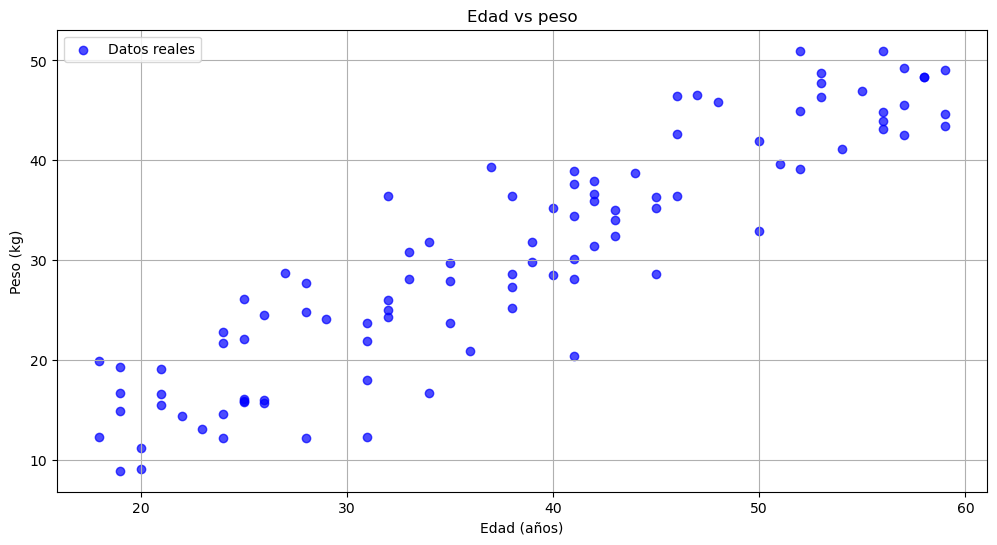

In [34]:

# Graficar
plt.figure(figsize=(12, 6))

# Gráfica de datos con ambas regresiones
plt.scatter(edad, peso, color='blue', label='Datos reales', alpha=0.7)
plt.title('Edad vs peso')
plt.xlabel('Edad (años)')
plt.ylabel('Peso (kg)')
plt.legend()
plt.grid(True)
plt.show()


# Comparando regresiones

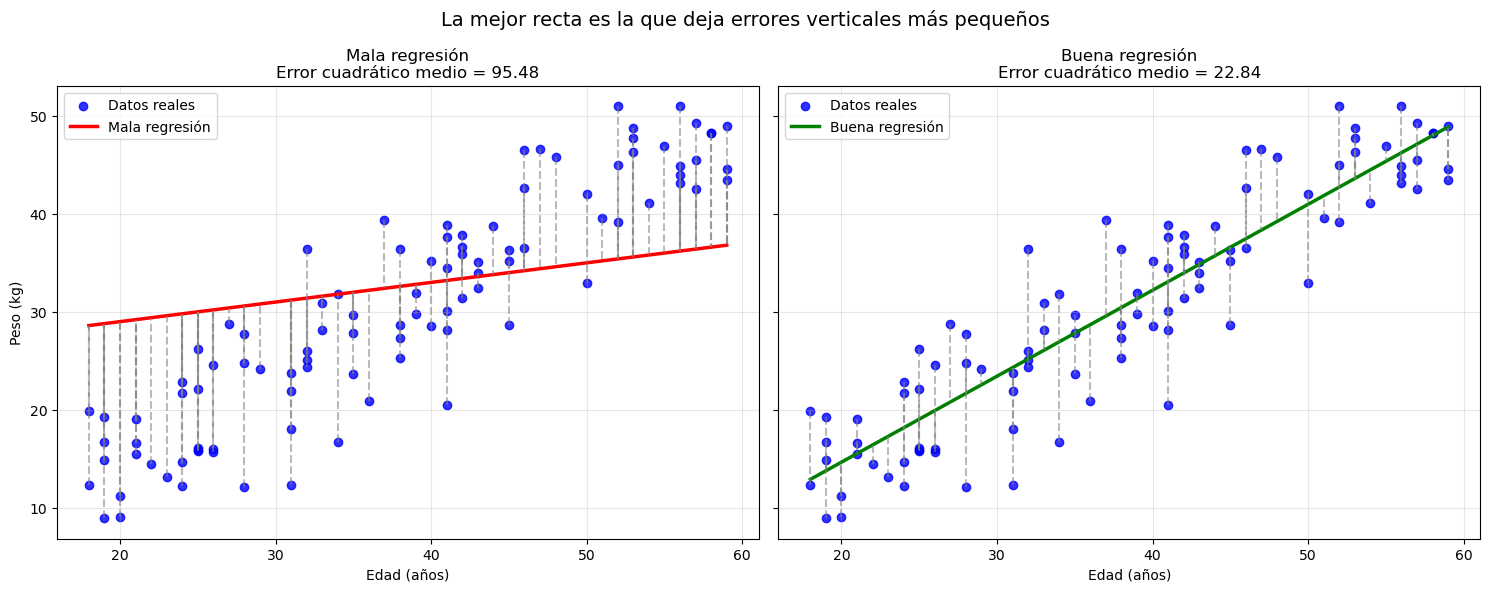

In [35]:
# Comparar visualmente una regresión buena y una mala usando errores verticales
orden = np.argsort(edad)
edad_ordenada = edad[orden]
peso_ordenado = peso[orden]
pred_buena_ordenada = peso_pred_bueno[orden]
pred_mala_ordenada = peso_pred_malo[orden]

mse_bueno = np.mean((peso - peso_pred_bueno) ** 2)
mse_malo = np.mean((peso - peso_pred_malo) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

configuraciones = [
    (axes[0], pred_mala_ordenada, 'Mala regresión', 'red', mse_malo),
    (axes[1], pred_buena_ordenada, 'Buena regresión', 'green', mse_bueno),
]

for ax, pred, titulo, color, mse in configuraciones:
    ax.scatter(edad_ordenada, peso_ordenado, color='blue', label='Datos reales', alpha=0.8)
    ax.plot(edad_ordenada, pred, color=color, linewidth=2.5, label=titulo)

    # Cada línea vertical muestra el error de predicción para una observación.
    for x_i, y_real, y_pred in zip(edad_ordenada, peso_ordenado, pred):
        ax.plot([x_i, x_i], [y_real, y_pred], color='gray', linestyle='--', alpha=0.55)

    ax.set_title(f'{titulo}\nError cuadrático medio = {mse:.2f}')
    ax.set_xlabel('Edad (años)')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Peso (kg)')
plt.suptitle('La mejor recta es la que deja errores verticales más pequeños', fontsize=14)
plt.tight_layout()
plt.show()


In [36]:
# Crea un data frame con el real, prediccioens buenas y malas
df_viz=pd.DataFrame({
    'pred_mala': peso_pred_malo,
    'pred_buena': peso_pred_bueno,
    'peso':peso_ordenado
})  


In [37]:
(df_viz.pred_mala - df_viz.peso).mean()

np.float64(2.2121970994155116)

In [38]:
(df_viz.pred_buena - df_viz.peso).mean()

np.float64(7.460698725481052e-15)

In [39]:
# Error promedio del modelo 


In [40]:
# Error promedio del modelo malo 


In [41]:
# Vuelve a crear el data frame pero *agrega los errores cuadraticos*
df_viz['pred_mala_squared']=(df_viz.pred_mala - df_viz.peso)**2
df_viz['pred_buena_squared']=(df_viz.pred_buena - df_viz.peso)**2

# Midiendo el error cuadratico

In [42]:
df_viz['pred_mala_squared'].mean()

np.float64(150.6128786401291)

In [43]:
df_viz['pred_buena_squared'].mean()

np.float64(264.58169422203713)

# Corrigiendo con el cuadrado, obten algo más intuitivo

# Descenso en gradiente 

Iteración 0: Pérdida = 1058.85, w = 0.2562, b = 0.0061


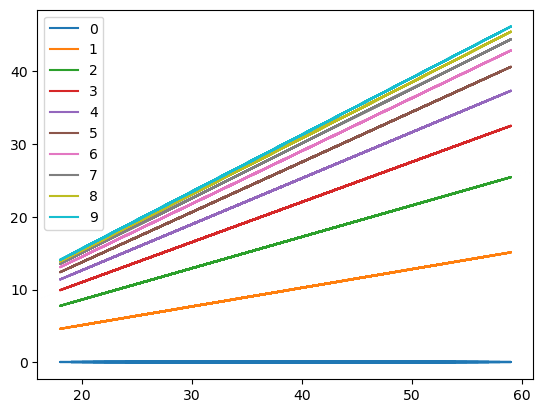

In [44]:
# Inicializar parámetros de la regresión lineal
w = 0  # Pendiente inicial
b = 0.0  # Intercepto inicial
tasa_aprendizaje = 0.0001  # Tasa de aprendizaje
iteraciones = 10  # Número de iteraciones

# Guardar valores de pérdida para graficar
perdidas = []
ws = []
bs = []
# Gradiente descendente
for i in range(iteraciones):
    # Predicciones
    y_pred = w * edad + b
    plt.plot(edad, y_pred, label=i)
    plt.legend(loc='best')

    # Calcular el error cuadrático medio (MSE)
    error = np.mean((peso - y_pred) ** 2)
    perdidas.append(error)

    # Calcular los gradientes
    gradiente_w = -2 * np.mean(edad * (peso - y_pred))  # Derivada parcial respecto a w
    gradiente_b = -2 * np.mean(peso - y_pred)          # Derivada parcial respecto a b

    # Actualizar los parámetros
    w = w - tasa_aprendizaje * gradiente_w
    b = b - tasa_aprendizaje * gradiente_b
    ws.append(w)
    bs.append(b)
    
    # Opcional: Mostrar cada 100 iteraciones
    if i % 100 == 0:
        print(f"Iteración {i}: Pérdida = {error:.2f}, w = {w:.4f}, b = {b:.4f}")

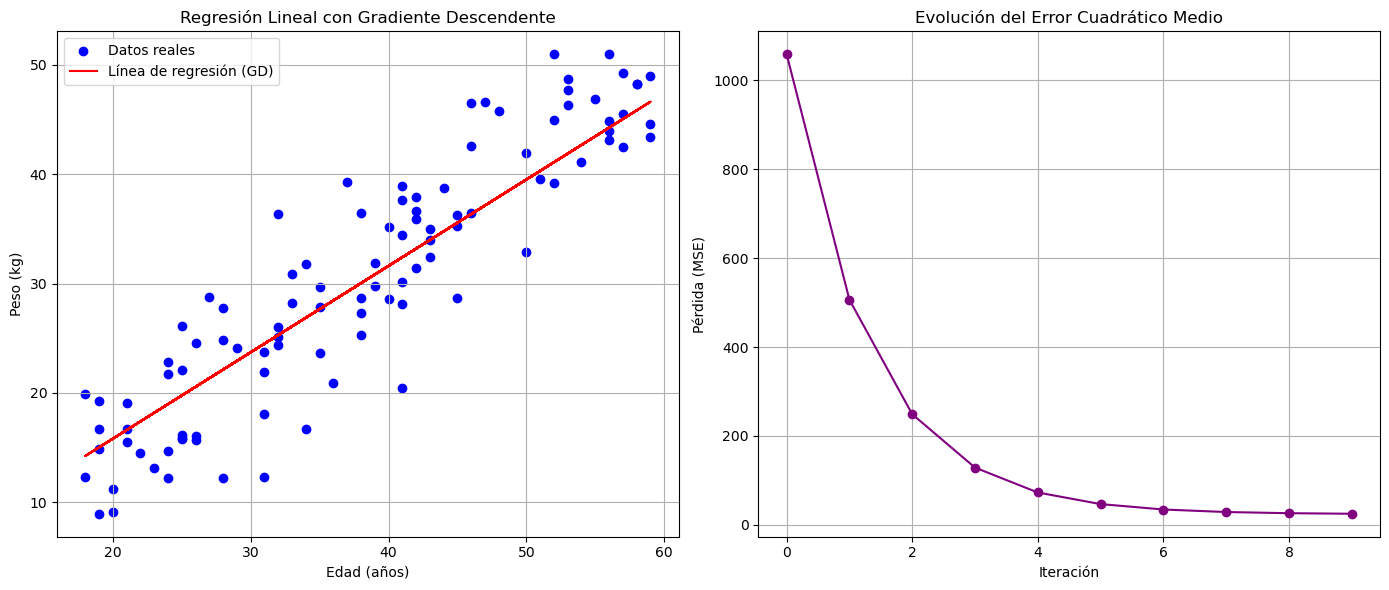

In [45]:

# Graficar los resultados
plt.figure(figsize=(14, 6))

# Gráfico 1: Ajuste del modelo a los datos
plt.subplot(1, 2, 1)
plt.scatter(edad, peso, color='blue', label='Datos reales')
plt.plot(edad, w * edad + b, color='red', label='Línea de regresión (GD)')
plt.title('Regresión Lineal con Gradiente Descendente')
plt.xlabel('Edad (años)')
plt.ylabel('Peso (kg)')
plt.legend()
plt.grid()

# Gráfico 2: Evolución de la pérdida
plt.subplot(1, 2, 2)
plt.plot(range(iteraciones), perdidas, color='purple', marker="o")
plt.title('Evolución del Error Cuadrático Medio')
plt.xlabel('Iteración')
plt.ylabel('Pérdida (MSE)')
plt.grid()

plt.tight_layout()
plt.show()

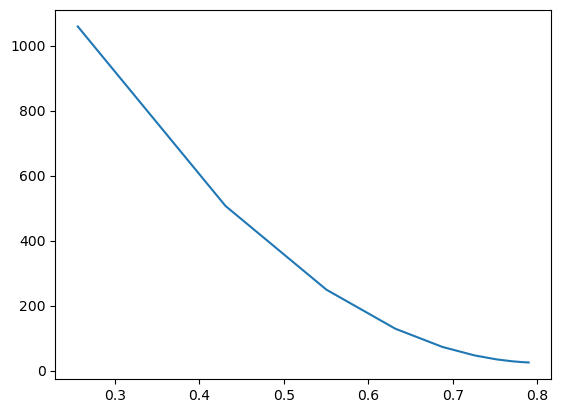

In [46]:
plt.plot(ws, perdidas)

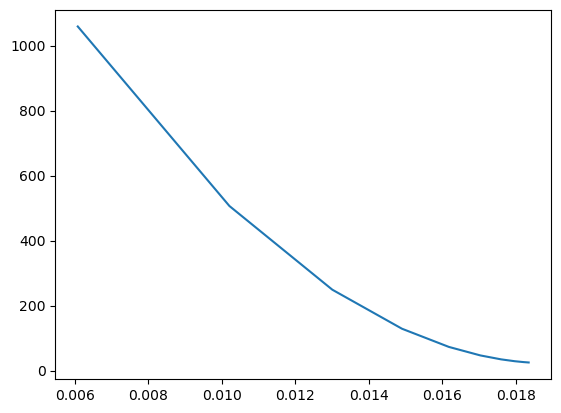

In [47]:
plt.plot(bs, perdidas)

In [48]:
!pwd

/Users/mafergomezf/Library/CloudStorage/OneDrive-ITESO/ITESOCARPETA/8tavo Semestre/PYTHON/LAB
